In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('./data/sign_mnist_train.csv')
test = pd.read_csv('./data/sign_mnist_test.csv')

In [3]:
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [4]:
# train = train.to_numpy()
# train = train / 255
# print(train)

In [5]:
train_label = tf.keras.utils.to_categorical(train['label'])
test_label = tf.keras.utils.to_categorical(test['label'])
train.drop('label', axis=1, inplace=True)
test.drop('label', axis=1, inplace=True)

In [6]:
train = tf.convert_to_tensor(train / 255.0)
test = tf.convert_to_tensor(test / 255.0)
test = tf.convert_to_tensor(test)

In [7]:
train = tf.reshape(train, [-1, 28, 28,1])
test = tf.reshape(test, [-1, 28, 28,1])

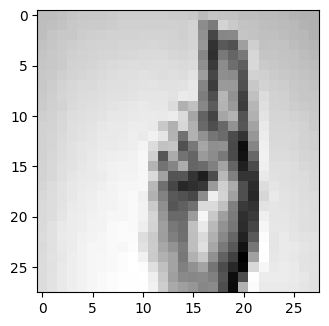

In [8]:
import random

def show_images(image):
    image = image.numpy().reshape(28,28)
    plt.figure(figsize=(8, 8))
    plt.subplot(1,2,2)
    plt.imshow(image, cmap='gray')

# for number_image in range(10):
#     show_images(train[number_image])

show_images(train[random.randrange(0,len(train)-1)])

In [9]:
train_label = tf.convert_to_tensor(train_label)
test_label = tf.convert_to_tensor(test_label)

In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((train, train_label))
test_ds = tf.data.Dataset.from_tensor_slices((test, test_label))

In [11]:
train.shape

TensorShape([27455, 28, 28, 1])

In [12]:
# image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1./255.0,
#     rotation_range=40,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     shear_range=0.2,
#     fill_mode='nearest'
# )

In [13]:
# train_ds = image_gen.flow(
#     x=train,
#     y=train_label,
#     batch_size=32
# )
# test_ds = image_gen.flow(
#     x=test,
#     y=test_label,
#     batch_size=32
# )

In [14]:
final_train_ds, final_val_ds = tf.keras.utils.split_dataset(train_ds, left_size=0.8)

In [15]:
final_train_ds = final_train_ds.shuffle(1000).batch(32)
final_val_ds = final_val_ds.batch(32)

In [16]:
aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [35]:
model = tf.keras.Sequential([])
model.add(tf.keras.Input(shape=(28,28,1)))
model.add(aug)
model.add(tf.keras.layers.Conv2D(32, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
# model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(25, activation='softmax'))

In [36]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [37]:
model.compile(loss='categorical_crossentropy', optimizer=adam_optimizer, metrics=['accuracy'])

In [38]:
history = model.fit(final_train_ds, epochs=10, validation_data=final_val_ds)

Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2595 - loss: 2.3520 - val_accuracy: 0.5529 - val_loss: 1.2951
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5868 - loss: 1.2110 - val_accuracy: 0.7893 - val_loss: 0.6292
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7502 - loss: 0.7140 - val_accuracy: 0.8516 - val_loss: 0.4198
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8292 - loss: 0.4965 - val_accuracy: 0.9078 - val_loss: 0.2889
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8742 - loss: 0.3702 - val_accuracy: 0.9022 - val_loss: 0.2629
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9034 - loss: 0.2858 - val_accuracy: 0.9445 - val_loss: 0.1750
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9204 - loss: 0.2363 - val_accuracy: 0.9634 - val_loss: 0.1139
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9304 - loss: 0.1992 - val_accuracy: 0.

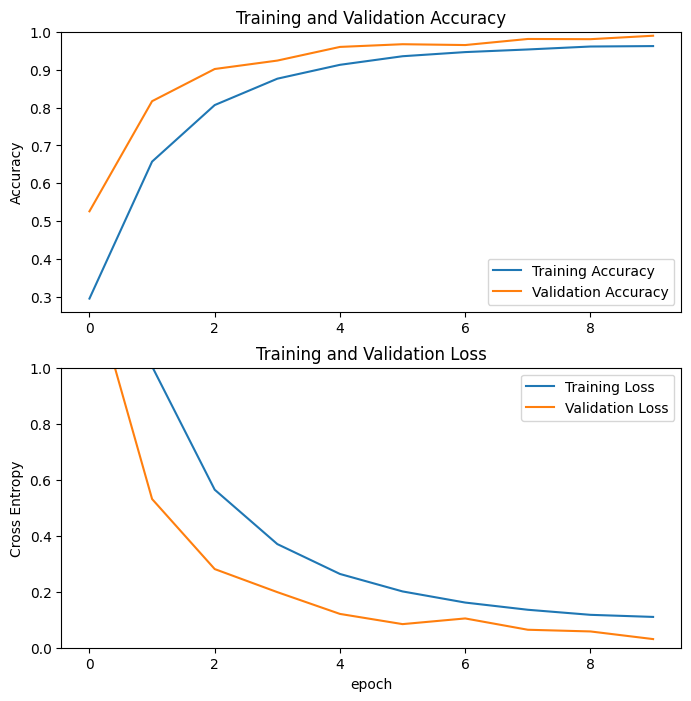

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [46]:
prediction = model.predict(test)
print(np.argmax(prediction[0]))

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6
